## Importing Libraries

In [31]:
import wfdb
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from collections import Counter
from collections import defaultdict

## Exploring the Dataset

All Samples have a sampling frequency of 300Hz but the lengths vary

In [32]:
# Read the ECG record
record = wfdb.rdrecord('ECG_Dataset/A00001')

In [33]:
# Extract signal
ecg_signal = record.p_signal[:, 0]   # single-lead ECG
fs = record.fs                       # sampling frequency

In [34]:
ecg_signal

array([-0.127, -0.162, -0.197, ..., -0.018, -0.022, -0.021], shape=(9000,))

In [35]:
record.p_signal

array([[-0.127],
       [-0.162],
       [-0.197],
       ...,
       [-0.018],
       [-0.022],
       [-0.021]], shape=(9000, 1))

In [36]:
record

In [37]:
print("Sampling Frequency:", fs)
print("Signal length:", len(ecg_signal))


Sampling Frequency: 300
Signal length: 9000


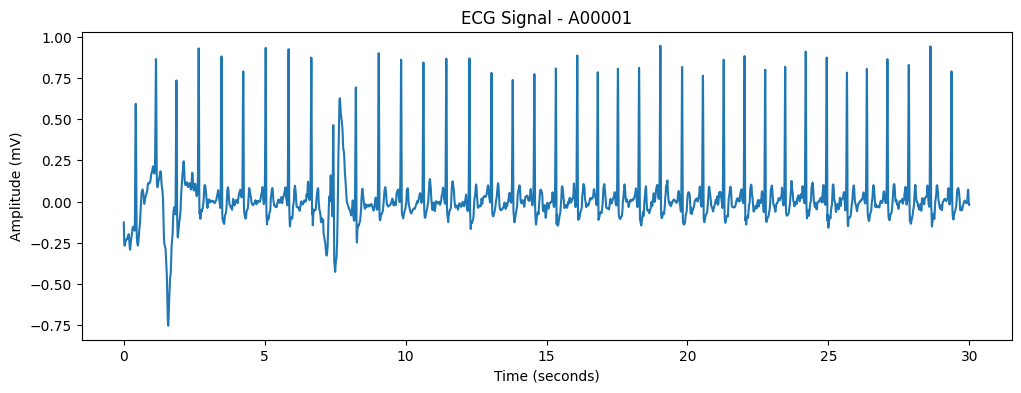

In [38]:
time = [i / fs for i in range(len(ecg_signal))]

plt.figure(figsize=(12, 4))
plt.plot(time, ecg_signal)
plt.xlabel("Time (seconds)")
plt.ylabel("Amplitude (mV)")
plt.title("ECG Signal - A00001")
plt.show()

### Waveform of the 4 Classifications

Sampling Frequency: 300
Signal length: 9000


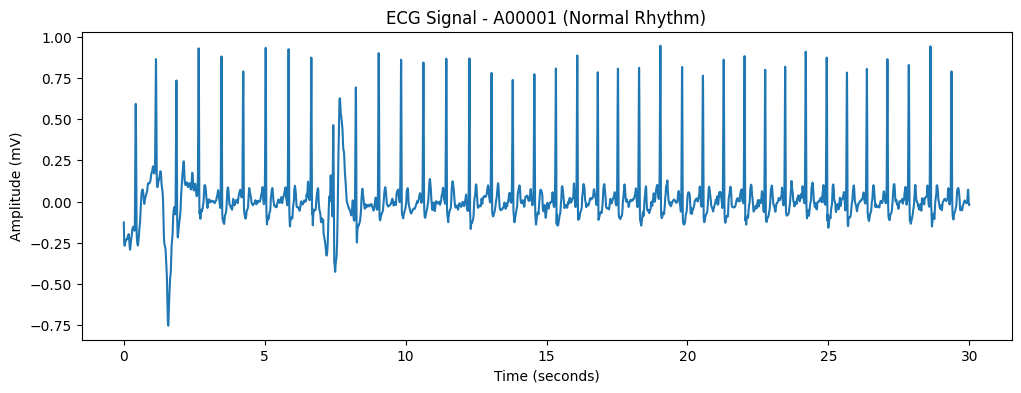

Sampling Frequency: 300
Signal length: 9000


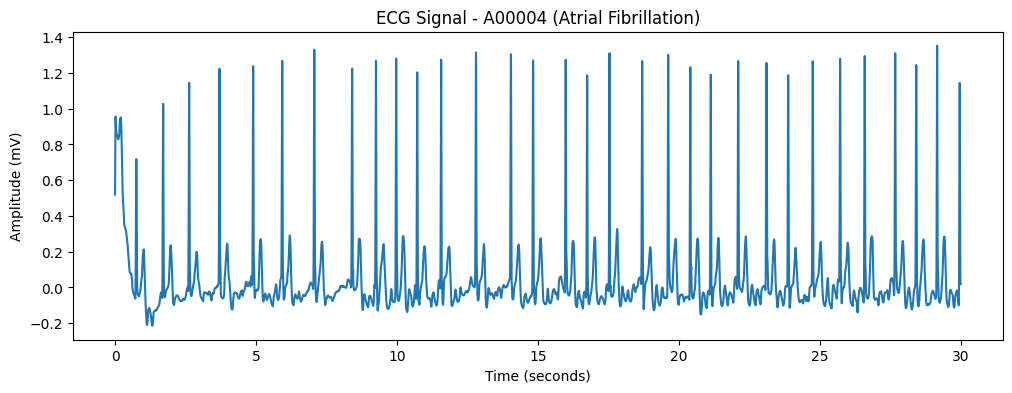

Sampling Frequency: 300
Signal length: 9000


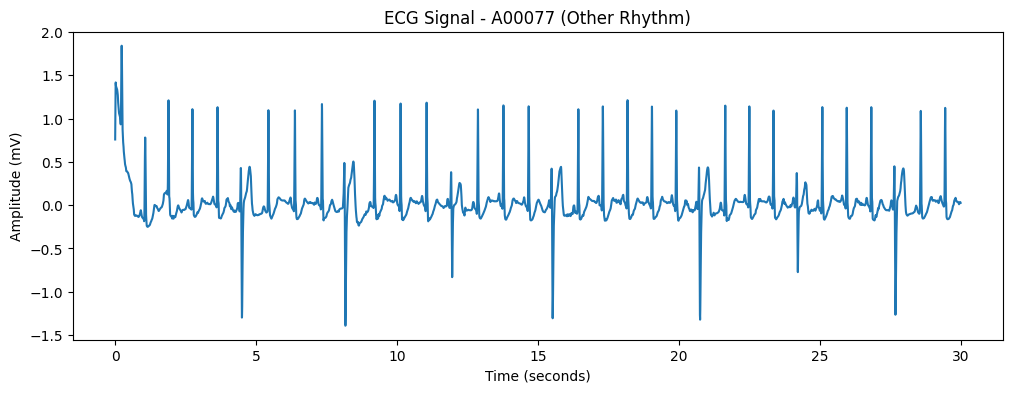

Sampling Frequency: 300
Signal length: 9000


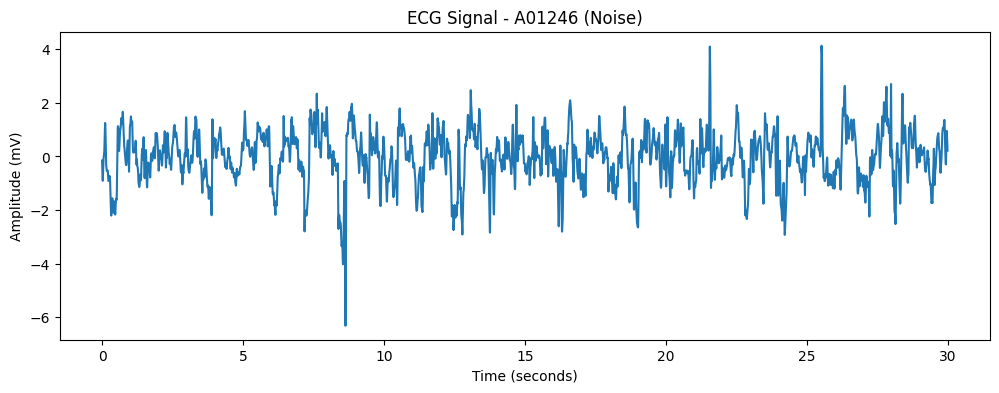

In [39]:
records = {
    "A00001": "Normal Rhythm",
    "A00004": "Atrial Fibrillation",
    "A00077": "Other Rhythm",
    "A01246": "Noise"
}

for record_name, label in records.items():

    record = wfdb.rdrecord(f"ECG_Dataset/{record_name}")

    ecg_signal = record.p_signal[:, 0]   # physical signal (mV)
    fs = record.fs

    print("Sampling Frequency:", fs)
    print("Signal length:", len(ecg_signal))

    time = [i / fs for i in range(len(ecg_signal))]

    plt.figure(figsize=(12, 4))
    plt.plot(time, ecg_signal)
    plt.xlabel("Time (seconds)")
    plt.ylabel("Amplitude (mV)")
    plt.title(f"ECG Signal - {record_name} ({label})")
    plt.show()


## Storing the Records

In [40]:
labels_df = pd.read_csv("ECG_Dataset/REFERENCE.csv", header=None, names=["record", "label"])

In [41]:
labels_df.head()

,record,label
0,A00001,N
1,A00002,N
2,A00003,N
3,A00004,A
4,A00005,A


In [42]:
label_map = dict(zip(labels_df["record"], labels_df["label"]))

In [43]:
records = []

for i in range(1, 8529):
    record_id = f"A{i:05d}"
    record_path = f"ECG_Dataset/{record_id}"

    record = wfdb.rdrecord(record_path)
    ecg_signal = record.p_signal[:, 0]

    records.append({
        "record_id": record_id,
        "label": label_map.get(record_id, None),
        "length": len(ecg_signal),
        "signal": ecg_signal
    })

    if i % 100 == 0:
        print(f"Processed {i} records...")

Processed 100 records...
Processed 200 records...
Processed 300 records...
Processed 400 records...
Processed 500 records...
Processed 600 records...
Processed 700 records...
Processed 800 records...
Processed 900 records...
Processed 1000 records...
Processed 1100 records...
Processed 1200 records...
Processed 1300 records...
Processed 1400 records...
Processed 1500 records...
Processed 1600 records...
Processed 1700 records...
Processed 1800 records...
Processed 1900 records...
Processed 2000 records...
Processed 2100 records...
Processed 2200 records...
Processed 2300 records...
Processed 2400 records...
Processed 2500 records...
Processed 2600 records...
Processed 2700 records...
Processed 2800 records...
Processed 2900 records...
Processed 3000 records...
Processed 3100 records...
Processed 3200 records...
Processed 3300 records...
Processed 3400 records...
Processed 3500 records...
Processed 3600 records...
Processed 3700 records...
Processed 3800 records...
Processed 3900 record

In [44]:
df = pd.DataFrame(records)
df

,record_id,label,length,signal
0,A00001,N,9000,"[-0.127, -0.162, -0.197, -0.229, -0.245, -0.25..."
1,A00002,N,9000,"[0.128, 0.157, 0.189, 0.226, 0.25, 0.257, 0.26..."
2,A00003,N,18000,"[0.056, 0.073, 0.085, 0.093, 0.1, 0.107, 0.113..."
3,A00004,A,9000,"[0.519, 0.619, 0.723, 0.827, 0.914, 0.956, 0.9..."
4,A00005,A,18000,"[-0.188, -0.239, -0.274, -0.316, -0.356, -0.37..."
...,...,...,...,...
8523,A08524,N,9000,"[-0.104, -0.127, -0.144, -0.154, -0.16, -0.164..."
8524,A08525,O,9000,"[-0.121, -0.197, -0.288, -0.39, -0.496, -0.6, ..."
8525,A08526,N,10904,"[-0.202, -0.235, -0.272, -0.305, -0.325, -0.33..."
8526,A08527,N,9000,"[-0.227, -0.297, -0.374, -0.449, -0.505, -0.52..."


In [45]:
df['signal'][3440]

array([0.028, 0.031, 0.033, ..., 0.006, 0.004, 0.003], shape=(9000,))

### Save as csv + npy

In [46]:
df.drop(columns=["signal"]).to_csv("ECG_Processed_Dataset/ecg_meta.csv", index=False)

In [47]:
np.save("ECG_Processed_Dataset/ecg_signals.npy", df["signal"].to_numpy(), allow_pickle=True)

### Reload

In [48]:
meta = pd.read_csv("ECG_Processed_Dataset/ecg_meta.csv")
signals = np.load("ECG_Processed_Dataset/ecg_signals.npy", allow_pickle=True)

meta["signal"] = signals
df = meta

In [49]:
df

,record_id,label,length,signal
0,A00001,N,9000,"[-0.127, -0.162, -0.197, -0.229, -0.245, -0.25..."
1,A00002,N,9000,"[0.128, 0.157, 0.189, 0.226, 0.25, 0.257, 0.26..."
2,A00003,N,18000,"[0.056, 0.073, 0.085, 0.093, 0.1, 0.107, 0.113..."
3,A00004,A,9000,"[0.519, 0.619, 0.723, 0.827, 0.914, 0.956, 0.9..."
4,A00005,A,18000,"[-0.188, -0.239, -0.274, -0.316, -0.356, -0.37..."
...,...,...,...,...
8523,A08524,N,9000,"[-0.104, -0.127, -0.144, -0.154, -0.16, -0.164..."
8524,A08525,O,9000,"[-0.121, -0.197, -0.288, -0.39, -0.496, -0.6, ..."
8525,A08526,N,10904,"[-0.202, -0.235, -0.272, -0.305, -0.325, -0.33..."
8526,A08527,N,9000,"[-0.227, -0.297, -0.374, -0.449, -0.505, -0.52..."
